# Detección de fraude en tarjetas de crédito con una Red Neuronal
**Tarea de Redes Neuronales Artificiales — Dr. Jorge Velazquez-Castro**

Dataset: [Credit Card Fraud Detection (mlg-ulb)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Este cuaderno entrena **varios modelos** y muestra las curvas de **loss** y **accuracy** (entrenamiento y validación), registrando todo en **MLflow**.

**Cómo ejecutarlo:** `Entorno de ejecución > Ejecutar todo`. Cuando se te pida, sube el archivo `creditcard.csv`.

In [1]:

!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.4/9

In [5]:

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score
import mlflow


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
df = pd.read_csv("/content/drive/MyDrive/Tarea6_DGC/creditcard.csv")
print(f'Dim: {df.shape}')
df.head()

Dim: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
mlflow.set_experiment('fraude_tarjetas_rnn')

fraude = int(df['Class'].sum())
print('Filas:', len(df), '| Fraudes:', fraude, '(', round(100*fraude/len(df), 3), '%)')

# 'V1'..'V28' provienen de un PCA (ya escaladas). Escalamos 'Amount' y 'Time'.
scaler = RobustScaler()
df[['Amount','Time']] = scaler.fit_transform(df[['Amount','Time']])
X = df.drop(columns=['Class']).values.astype('float32')
y = df['Class'].values.astype('int32')

# 60% train / 20% val / 20% test (estratificado)
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.40, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print('train', len(y_train), '| val', len(y_val), '| test', len(y_test))

Filas: 284807 | Fraudes: 492 ( 0.173 %)
train 170884 | val 56961 | test 56962


In [12]:
# 4) Modelo (MLP) y utilidades para el desbalance y las gráficas
def build_model(input_dim, hidden=(32,16), dropout=0.0, lr=1e-3):
    m = keras.Sequential(name='mlp_fraude')
    m.add(keras.Input(shape=(input_dim,)))
    for i, u in enumerate(hidden):
        m.add(layers.Dense(u, activation='relu', name=f'densa_{i+1}'))
        if dropout > 0:
            m.add(layers.Dropout(dropout, name=f'dropout_{i+1}'))
    m.add(layers.Dense(1, activation='sigmoid', name='salida'))
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc'),
                       keras.metrics.Precision(name='precision'),
                       keras.metrics.Recall(name='recall')])
    return m

def class_weights(y):
    neg, pos = np.bincount(y)
    total = neg + pos
    return {0: total/(2.0*neg), 1: total/(2.0*pos)}

def undersample(X, y, ratio=1.0, seed=SEED):
    rng = np.random.default_rng(seed)
    pos = np.where(y==1)[0]; neg = np.where(y==0)[0]
    neg = rng.choice(neg, size=min(len(neg), int(len(pos)*ratio)), replace=False)
    keep = np.concatenate([pos, neg]); rng.shuffle(keep)
    return X[keep], y[keep]

def plot_history(h, name):
    e = range(1, len(h.history['loss'])+1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
    a1.plot(e, h.history['loss'], 'o-', label='Entrenamiento')
    a1.plot(e, h.history['val_loss'], 's-', label='Validación')
    a1.set_title('Loss — '+name); a1.set_xlabel('Época'); a1.set_ylabel('Loss'); a1.legend(); a1.grid(alpha=0.3)
    a2.plot(e, h.history['accuracy'], 'o-', label='Entrenamiento')
    a2.plot(e, h.history['val_accuracy'], 's-', label='Validación')
    a2.set_title('Accuracy — '+name); a2.set_xlabel('Época'); a2.set_ylabel('Accuracy'); a2.legend(); a2.grid(alpha=0.3)
    fig.tight_layout()
    os.makedirs('results', exist_ok=True)
    fig.savefig('results/curvas_'+name+'.png', dpi=120)
    plt.show()


==== baseline — MLP simple, sin tratar el desbalance ====
Epoch 1/40
84/84 - 10s - 121ms/step - accuracy: 0.9918 - auc: 0.3045 - loss: 0.1410 - precision: 0.0072 - recall: 0.0271 - val_accuracy: 0.9983 - val_auc: 0.5916 - val_loss: 0.0289 - val_precision: 1.0000 - val_recall: 0.0306
Epoch 2/40
84/84 - 0s - 5ms/step - accuracy: 0.9986 - auc: 0.8184 - loss: 0.0158 - precision: 0.8353 - recall: 0.2407 - val_accuracy: 0.9987 - val_auc: 0.8335 - val_loss: 0.0108 - val_precision: 0.7255 - val_recall: 0.3776
Epoch 3/40
84/84 - 0s - 4ms/step - accuracy: 0.9990 - auc: 0.8949 - loss: 0.0076 - precision: 0.8500 - recall: 0.5186 - val_accuracy: 0.9990 - val_auc: 0.8648 - val_loss: 0.0077 - val_precision: 0.7703 - val_recall: 0.5816
Epoch 4/40
84/84 - 0s - 4ms/step - accuracy: 0.9992 - auc: 0.9049 - loss: 0.0055 - precision: 0.8649 - recall: 0.6508 - val_accuracy: 0.9990 - val_auc: 0.8724 - val_loss: 0.0065 - val_precision: 0.7722 - val_recall: 0.6224
Epoch 5/40
84/84 - 0s - 5ms/step - accuracy: 0

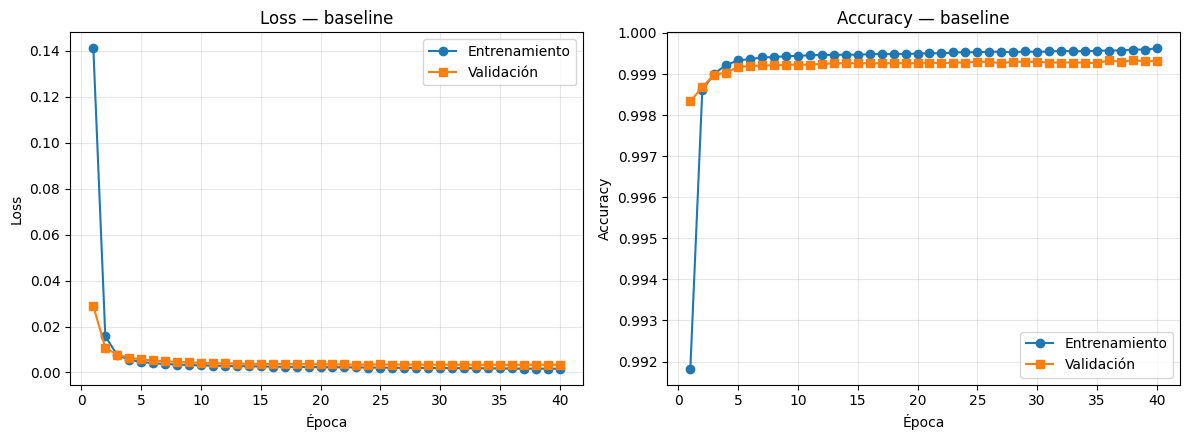

  matriz de confusión (test):
 [[56847    16]
 [   17    82]]
  ROC-AUC 0.9711 | PR-AUC 0.8509 | recall 0.8283 | precision 0.8367

==== pesos_clase — MLP + pesos de clase ====
  pesos de clase: {0: np.float64(0.5008646512963908), 1: np.float64(289.63389830508476)}
Epoch 1/40
84/84 - 5s - 62ms/step - accuracy: 0.6270 - auc: 0.8270 - loss: 0.5090 - precision: 0.0037 - recall: 0.7966 - val_accuracy: 0.8905 - val_auc: 0.9196 - val_loss: 0.4905 - val_precision: 0.0135 - val_recall: 0.8673
Epoch 2/40
84/84 - 0s - 5ms/step - accuracy: 0.9569 - auc: 0.9540 - loss: 0.2917 - precision: 0.0345 - recall: 0.8881 - val_accuracy: 0.9744 - val_auc: 0.9562 - val_loss: 0.2829 - val_precision: 0.0556 - val_recall: 0.8673
Epoch 3/40
84/84 - 0s - 5ms/step - accuracy: 0.9808 - auc: 0.9736 - loss: 0.2018 - precision: 0.0743 - recall: 0.8847 - val_accuracy: 0.9778 - val_auc: 0.9759 - val_loss: 0.1896 - val_precision: 0.0644 - val_recall: 0.8776
Epoch 4/40
84/84 - 0s - 5ms/step - accuracy: 0.9809 - auc: 0.9832

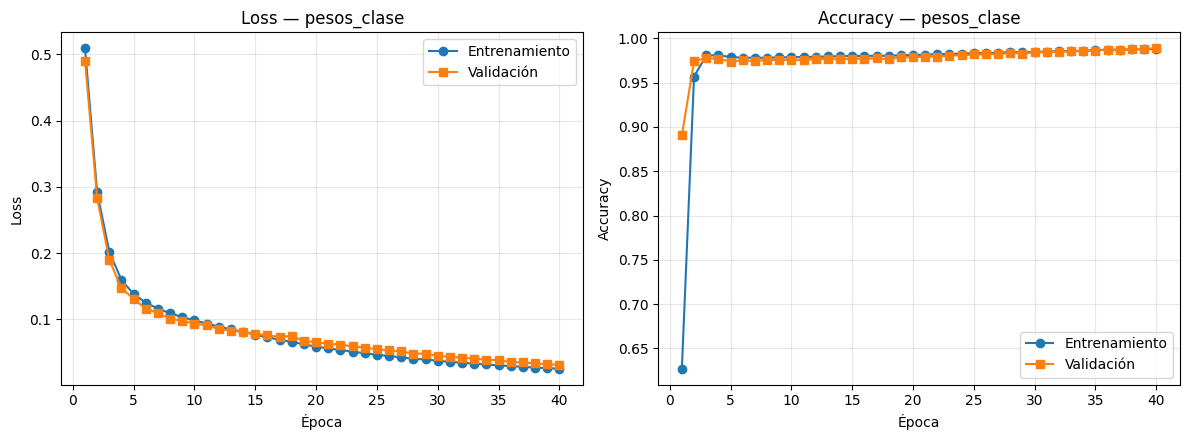

  matriz de confusión (test):
 [[56273   590]
 [   11    88]]
  ROC-AUC 0.9651 | PR-AUC 0.7406 | recall 0.8889 | precision 0.1298

==== profundo_dropout — Red más profunda + dropout + pesos ====
  pesos de clase: {0: np.float64(0.5008646512963908), 1: np.float64(289.63389830508476)}
Epoch 1/40
84/84 - 10s - 125ms/step - accuracy: 0.6035 - auc: 0.8716 - loss: 0.4826 - precision: 0.0037 - recall: 0.8576 - val_accuracy: 0.9731 - val_auc: 0.9507 - val_loss: 0.3577 - val_precision: 0.0530 - val_recall: 0.8673
Epoch 2/40
84/84 - 1s - 7ms/step - accuracy: 0.9031 - auc: 0.9412 - loss: 0.3217 - precision: 0.0155 - recall: 0.8814 - val_accuracy: 0.9809 - val_auc: 0.9656 - val_loss: 0.2108 - val_precision: 0.0719 - val_recall: 0.8469
Epoch 3/40
84/84 - 0s - 5ms/step - accuracy: 0.9492 - auc: 0.9632 - loss: 0.2311 - precision: 0.0289 - recall: 0.8712 - val_accuracy: 0.9759 - val_auc: 0.9721 - val_loss: 0.1377 - val_precision: 0.0577 - val_recall: 0.8469
Epoch 4/40
84/84 - 0s - 5ms/step - accuracy:

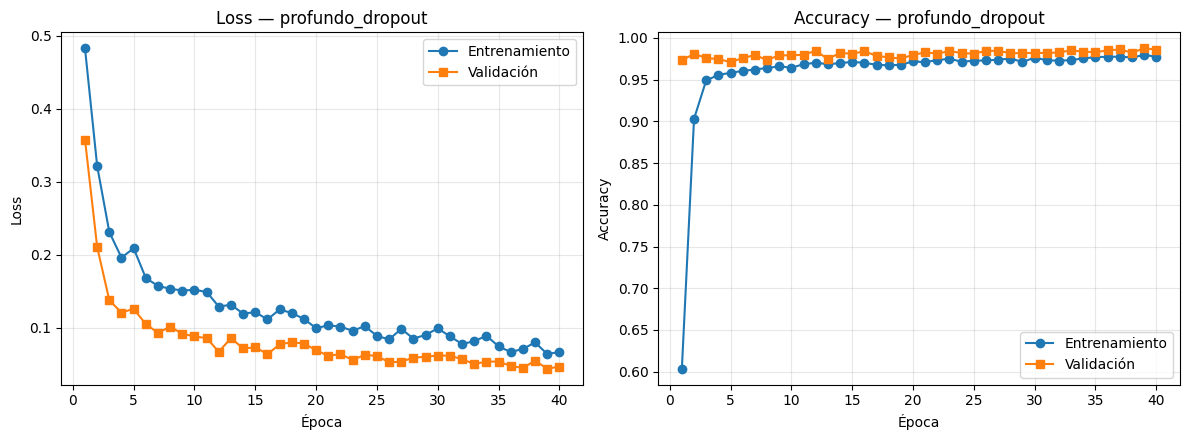

  matriz de confusión (test):
 [[56108   755]
 [    9    90]]
  ROC-AUC 0.9701 | PR-AUC 0.7557 | recall 0.9091 | precision 0.1065

==== submuestreo — Datos balanceados por submuestreo ====
  train balanceado: 590
Epoch 1/40
1/1 - 6s - 6s/step - accuracy: 0.4610 - auc: 0.2737 - loss: 1.4081 - precision: 0.3925 - recall: 0.1424 - val_accuracy: 0.8502 - val_auc: 0.2891 - val_loss: 0.4817 - val_precision: 0.0011 - val_recall: 0.0918
Epoch 2/40
1/1 - 0s - 175ms/step - accuracy: 0.4508 - auc: 0.2966 - loss: 1.3560 - precision: 0.3739 - recall: 0.1458 - val_accuracy: 0.8377 - val_auc: 0.3339 - val_loss: 0.4913 - val_precision: 0.0017 - val_recall: 0.1633
Epoch 3/40
1/1 - 0s - 164ms/step - accuracy: 0.5000 - auc: 0.3421 - loss: 1.2524 - precision: 0.5000 - recall: 0.2034 - val_accuracy: 0.8250 - val_auc: 0.3707 - val_loss: 0.5009 - val_precision: 0.0019 - val_recall: 0.1939
Epoch 4/40
1/1 - 0s - 162ms/step - accuracy: 0.5000 - auc: 0.3639 - loss: 1.1687 - precision: 0.5000 - recall: 0.2610 - v

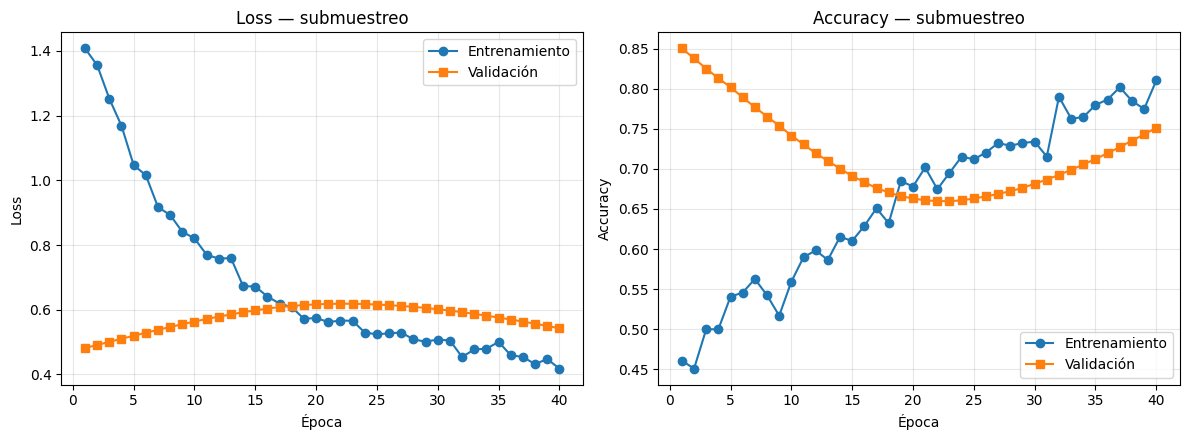

  matriz de confusión (test):
 [[42648 14215]
 [    8    91]]
  ROC-AUC 0.9464 | PR-AUC 0.1989 | recall 0.9192 | precision 0.0064

✅ Entrenamientos completados: 4


In [14]:
# 5) VARIOS entrenamientos + gráficas de loss/accuracy (train y val). MLflow es opcional.
import os
from contextlib import nullcontext
os.makedirs('results', exist_ok=True)

EXPERIMENTS = [
    dict(name='baseline',         desc='MLP simple, sin tratar el desbalance', hidden=(32,16), dropout=0.0),
    dict(name='pesos_clase',      desc='MLP + pesos de clase',                 hidden=(32,16), dropout=0.0, class_weight=True),
    dict(name='profundo_dropout', desc='Red más profunda + dropout + pesos',   hidden=(64,32,16), dropout=0.3, class_weight=True),
    dict(name='submuestreo',      desc='Datos balanceados por submuestreo',    hidden=(32,16), dropout=0.2, undersample=True),
]
EPOCHS, BATCH = 40, 2048
resumen = []

def mlrun(name):
    try:
        return mlflow.start_run(run_name=name)
    except Exception as e:
        print('  (MLflow desactivado:', e, ')'); return nullcontext()

for cfg in EXPERIMENTS:
    print('\n====', cfg['name'], '—', cfg['desc'], '====')
    keras.backend.clear_session(); np.random.seed(SEED); tf.random.set_seed(SEED)
    Xtr, ytr, cw = X_train, y_train, None
    if cfg.get('undersample'):
        Xtr, ytr = undersample(X_train, y_train); print('  train balanceado:', len(ytr))
    if cfg.get('class_weight'):
        cw = class_weights(y_train); print('  pesos de clase:', cw)
    model = build_model(X_train.shape[1], cfg.get('hidden',(32,16)), cfg.get('dropout',0.0))

    with mlrun(cfg['name']):
        try:
            mlflow.log_params(dict(hidden=str(cfg.get('hidden')), dropout=cfg.get('dropout',0.0),
                                   epochs=EPOCHS, batch=BATCH,
                                   class_weight=bool(cfg.get('class_weight')),
                                   undersample=bool(cfg.get('undersample'))))
        except Exception: pass

        hist = model.fit(Xtr, ytr, validation_data=(X_val, y_val),
                         epochs=EPOCHS, batch_size=BATCH, class_weight=cw, verbose=2)

        try:
            for metric, vals in hist.history.items():
                for step, v in enumerate(vals):
                    mlflow.log_metric(metric, float(v), step=step)
        except Exception as e:
            print('  (no se pudieron loguear métricas:', e, ')')

        try:
            plot_history(hist, cfg['name'])
            try: mlflow.log_artifact('results/curvas_'+cfg['name']+'.png', artifact_path='curvas')
            except Exception: pass
        except Exception as e:
            print('  (no se pudo graficar:', e, ')')

        # Evaluación en TEST (esto SIEMPRE se ejecuta y llena 'resumen')
        proba = model.predict(X_test, batch_size=4096, verbose=0).ravel()
        pred = (proba >= 0.5).astype(int)
        rep = classification_report(y_test, pred, target_names=['normal','fraude'],
                                    output_dict=True, zero_division=0)
        roc = roc_auc_score(y_test, proba); pr = average_precision_score(y_test, proba)
        m = dict(name=cfg['name'], roc_auc=roc, pr_auc=pr,
                 precision_fraude=rep['fraude']['precision'],
                 recall_fraude=rep['fraude']['recall'],
                 f1_fraude=rep['fraude']['f1-score'])
        try: mlflow.log_metrics({k: float(v) for k, v in m.items() if k != 'name'})
        except Exception: pass
        print('  matriz de confusión (test):\n', confusion_matrix(y_test, pred))
        print('  ROC-AUC %.4f | PR-AUC %.4f | recall %.4f | precision %.4f'
              % (roc, pr, m['recall_fraude'], m['precision_fraude']))
        resumen.append(m)

print('\n✅ Entrenamientos completados:', len(resumen))


                  roc_auc  pr_auc  precision_fraude  recall_fraude  f1_fraude
name                                                                         
baseline           0.9711  0.8509            0.8367         0.8283     0.8325
pesos_clase        0.9651  0.7406            0.1298         0.8889     0.2265
profundo_dropout   0.9701  0.7557            0.1065         0.9091     0.1907
submuestreo        0.9464  0.1989            0.0064         0.9192     0.0126


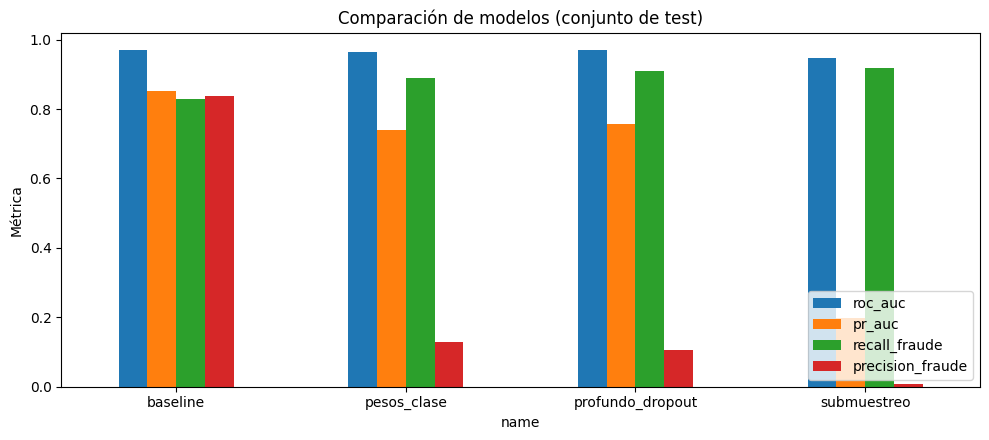

In [15]:
# 6) Resumen comparativo de los entrenamientos
res = pd.DataFrame(resumen).set_index('name').round(4)
res.to_csv('results/resumen.csv')
print(res.to_string())

ax = res[['roc_auc','pr_auc','recall_fraude','precision_fraude']].plot.bar(figsize=(10, 4.5), rot=0)
ax.set_title('Comparación de modelos (conjunto de test)'); ax.set_ylabel('Métrica'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('results/comparacion.png', dpi=120); plt.show()

In [16]:
!zip -r resultados.zip results mlruns
from google.colab import files; files.download('resultados.zip')

  adding: results/ (stored 0%)
  adding: results/comparacion.png (deflated 18%)
  adding: results/curvas_profundo_dropout.png (deflated 10%)
  adding: results/curvas_baseline.png (deflated 14%)
  adding: results/curvas_submuestreo.png (deflated 9%)
  adding: results/resumen.csv (deflated 38%)
  adding: results/curvas_pesos_clase.png (deflated 12%)
  adding: mlruns/ (stored 0%)
  adding: mlruns/1/ (stored 0%)
  adding: mlruns/1/4dc329f267704f1782b1f58d987d423c/ (stored 0%)
  adding: mlruns/1/4dc329f267704f1782b1f58d987d423c/artifacts/ (stored 0%)
  adding: mlruns/1/4dc329f267704f1782b1f58d987d423c/artifacts/curvas/ (stored 0%)
  adding: mlruns/1/4dc329f267704f1782b1f58d987d423c/artifacts/curvas/curvas_baseline.png (deflated 14%)
  adding: mlruns/1/8c12873a5631482db4a2e093600fa970/ (stored 0%)
  adding: mlruns/1/8c12873a5631482db4a2e093600fa970/artifacts/ (stored 0%)
  adding: mlruns/1/8c12873a5631482db4a2e093600fa970/artifacts/curvas/ (stored 0%)
  adding: mlruns/1/8c12873a5631482db4a2e

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>